In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from scipy.stats import mode
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

In [3]:
class LinearRegression:
    
    def __init__(self, X, Y,n_iterations, learning_rate):
        self.X=X
        self.Y=Y
        self.b=None
        self.w=None
        self.n_iterations=n_iterations
        self.learning_rate=learning_rate
    
    def predict(self, x):
        return x @ self.w + self.b
    
    def mse(self, n_samples, y_pred, y):
        return np.mean((y-y_pred)**2)
    
    def fit(self, X, Y):
        # initialise parameters
        n_samples, n_features=X.shape
        self.w=np.zeros(n_features)
        self.b=0
        
        # iterate through number of iterations
        for i in range(self.n_iterations):
            y_pred=self.predict(self.X)
            
            
            dw = (1/n_samples)*(X.T @ (Y-y_pred))
            db = (1/n_samples)*(np.sum(Y-y_pred))
            
            self.w += self.learning_rate*dw
            self.b += self.learning_rate*db
        
    def closed_form(self,X, Y):
        return np.linalg.pinv(X)



(500, 1) (500,)


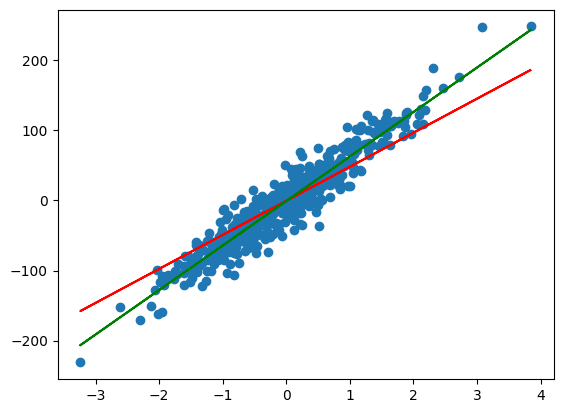

In [4]:
X,Y=make_regression(n_samples=500, n_features=1, noise=20,random_state=42)
plt.scatter(X,Y)

lr = LinearRegression(X,Y,n_iterations=150, learning_rate=0.01)
print(X.shape,Y.shape)
lr.fit(X,Y)
predictions=lr.predict(X)
plt.plot(X,predictions,color='r')
X_b = np.c_[X,np.ones((X.shape[0],1))]
weights = np.linalg.pinv(X_b)@Y

closed_form_pred = X_b @weights
plt.plot(X,closed_form_pred, color='g')
plt.show()

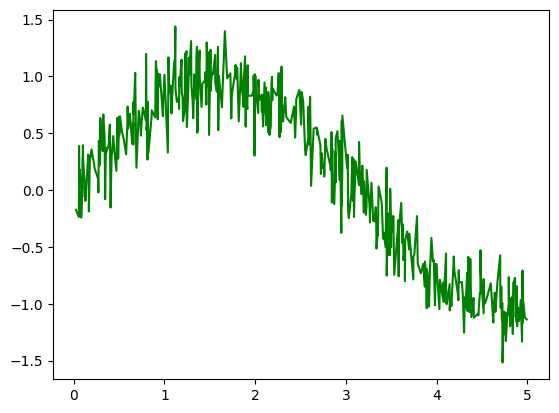

In [5]:
np.random.seed(0)
X_poly = np.sort(5 * np.random.rand(500, 1), axis=0)
Y_poly = np.sin(X_poly).ravel() + np.random.normal(0, 0.2, X_poly.shape[0])
plt.plot(X_poly,Y_poly,color='g' )


In [112]:
class PolynomialRegression:
    def __init__(self, p, learning_rate, n_iterations):
        self.p=p
        self.learning_rate=learning_rate
        self.n_iterations=n_iterations
        self.w=None
        self.b=None
        
    def transform_features(self,X):
        X = (X-self.mean)/self.std
        X_final=X[:,0].reshape(-1,1)

        for i in range(2,self.p+1):
            X_final = np.hstack((X_final, (X[:,0]**i).reshape(-1,1)))
        print(X_final.shape)
        return X_final
    
    def predict(self, x):
        
        return x @ self.w + self.b
    
    def fit(self,X,Y):
        self.mean=X.mean()
        self.std=X.std()
        X_transformed=self.transform_features(X)
        
        n_samples, n_features = X_transformed.shape
        self.w=np.zeros(n_features)
        self.b=0
        
        for i in range(self.n_iterations):
            y_pred=X_transformed @ self.w + self.b
            
            dw=(1/n_samples)*X_transformed.T @ (y_pred - Y)
            db = (1/n_samples) * np.sum(y_pred-Y)
            
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
            if i % 100 == 0:
                loss = (1/(2*n_samples)) * np.sum((y_pred - Y)**2)
                 
                sse = np.sum((Y-y_pred)**2)
                sst = np.sum((Y-Y.mean())**2)
                R2 = 1-(sse/(Y.var()*Y.shape[0]))
                print(f"Iteration {i},  Loss: {loss}, R2: {R2}")
                 
        

(500, 5)
Iteration 0,  Loss: 0.2812241886081018, R2: -0.034364798237239036
Iteration 100,  Loss: 0.09593011570981612, R2: 0.6471614505417393
Iteration 200,  Loss: 0.06004886853184453, R2: 0.7791355143000438
Iteration 300,  Loss: 0.045294890975787025, R2: 0.8334018101457225
Iteration 400,  Loss: 0.03867721169142826, R2: 0.8577421577226638
Iteration 500,  Loss: 0.035368329309532855, R2: 0.8699124887111889
Iteration 600,  Loss: 0.033474702477382254, R2: 0.8768773979029214
Iteration 700,  Loss: 0.03221963058178447, R2: 0.8814936515562383
Iteration 800,  Loss: 0.031272895224419665, R2: 0.8849758190459963
Iteration 900,  Loss: 0.030489723276298026, R2: 0.8878563873858442
(500, 5)


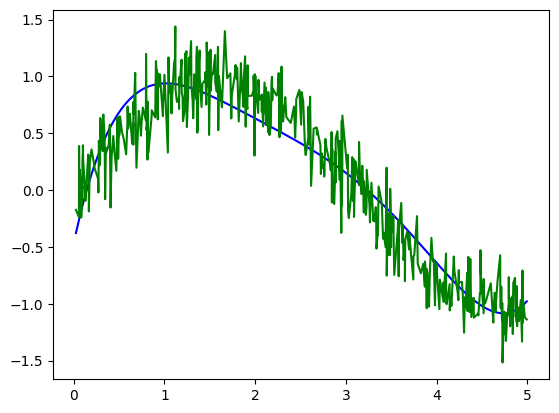

In [113]:
pr = PolynomialRegression(p=5, learning_rate=0.01, n_iterations=1000)
pr.fit(X_poly, Y_poly)
Y_pred_poly = pr.predict(pr.transform_features(X_poly))
plt.plot(X_poly, Y_pred_poly, color='b')
plt.plot(X_poly,Y_poly,color='g' )
plt.show()


In [ ]:


class LogisticRegression:
    def __init__(self,n_iterations, learning_rate):
        self.n_iterations=n_iterations
        self.learning_rate=learning_rate
        self.w=None

    def sigmoid(self,X):
        return 1/(1+np.exp(-(X @ self.w)))
    
    def log_loss(self,p,y,n_samples):
        return (-1/n_samples)*(y @ np.log(p) + (1-y) @ np.log(1-p))
    
    def fit(self,X,Y):
        n_samples,n_features=X.shape
        X = np.hstack((X[:,:],np.ones((n_samples, 1))))

        self.w = np.zeros(X.shape[1])

        for i in range(self.n_iterations):
            predictions = self.sigmoid(X)
            d_w = (1/n_samples)* (X.T @ (predictions-Y))
            self.w -= self.learning_rate * d_w
            if i%100==0:
                print(i,"Log loss: ", self.log_loss(predictions, Y, n_samples))
        return self.w


['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
0 Log loss:  0.6931471805599452
100 Log loss:  0.6604389500656795
200 Log loss:  0.6309290916058357
300 Log loss:  0.6037002589261187
400 Log loss:  0.5785566272949769
500 Log loss:  0.5553152025778372
600 Log loss:  0.5338065657182339
700 Log loss:  0.5138750402119701
800 Log loss:  0.4953784214540983
900 Log loss:  0.4781874035716263
1000 Log loss:  0.4621848137804345
1100 Log loss:  0.44726473933565125
1200 Log loss:  0.4333316099897488
1300 Log loss:  0.42029928044904824
1400 Log loss:  0.40809014272690436
1500 Log loss:  0.3966342871841803
1600 Log loss:  0.3858687228846145
1700 Log loss:  0.37573666209420353
1800 Log loss:  0.36618686978206183
1900 Log loss:  0.3571730763762507
2000 Log loss:  0.34865345042019075
2100 Log loss:  0.3405901268740426
2200 Log loss:  0.332948786392001
2300 Log loss:  0.3256982808193202
2400 Log loss:  0.31881030027543694
2500 Log loss:  0.31225907743926345
2600 Log los

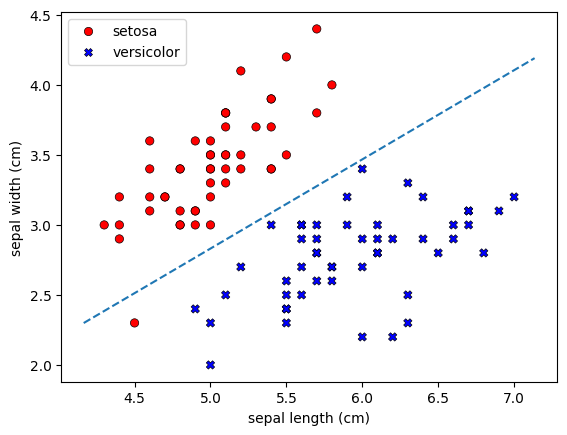

In [83]:
iris = load_iris()
print(iris.feature_names)
X = iris.data[:,:2]
y=iris.target  

X = X[(y==0) | (y==1)]
y = y[(y==0) | (y==1)]

lr=LogisticRegression(200000,0.005)
w=lr.fit(X,y)



sns.scatterplot(x=X[:,0],y=X[:,1],hue=iris.target_names[y],style=iris.target_names[y], palette=['red','blue'],edgecolor='k')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
x_line= np.array(plt.gca().get_xlim())
print(w)
line = -((w[0]/w[1])*x_line + (w[2]/w[1]))
plt.plot(x_line, line,ls='--')

[ 0.92139369 -1.55966163 -0.14346519]


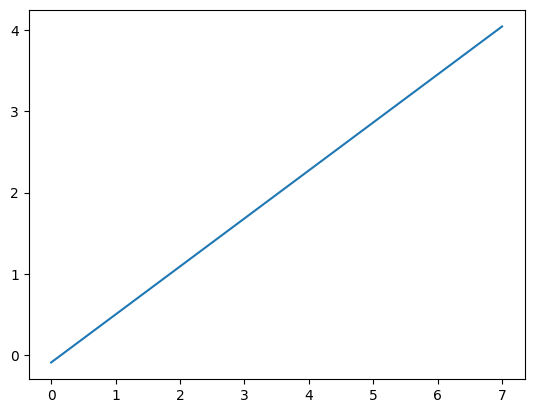

In [73]:
x_line = np.linspace(0,7,1000)
print(w)
line = -((w[0]/w[1])*x_line + (w[2]/w[1]))

plt.plot(x_line, line)

In [7]:
class KNN:
    def __init__(self,k):
        self.k=k
        
    def predict(self,x_train,y_train,x_test):
        distances=np.linalg.norm(x_train-x_test)
        kn = distances.argsort()[:self.k]
        labels = y_train[kn]
        return mode(labels)[0]
    
knn = KNN(2)
X_train = np.array([[1, 4, 1], [1, 0, -2], [0, 0, 1], [-1, 4, 0], [-1, -1, 1], [1, 2, 3], [0, -4, 0], [1, 0, -3]])
y_train = np.array([1, 0, 1, 1, 0, 1, 0, 0])
print(knn.predict(X_train, y_train, [0,0,1]))

1


In [10]:
clf = KNeighborsClassifier(n_neighbors=2)
clf.fit(X_train,y_train)
print(clf.score(X_train,y_train))

0.875


In [ ]:
import sklearn
from sklearn import datasets
import pandas as pd

df_ = datasets.load_iris()
df = pd.DataFrame()
df['petal_length'] = df_['data'][:,2]
df['petal_width'] = df_['data'][:,3]
df['target'] = df_['target'] == 1

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(df[['petal_length', 'petal_width']], 
                                        df['target'], 
                                        test_size=0.2,
                                        random_state=42)

# Normalise data
scaler = sklearn.preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)

svm_classifier = sklearn.svm.LinearSVC()


